# Задание 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(
    'train.csv',
    encoding='utf-8'
)

# Задание 2

In [5]:
row_count, column_count = df.shape
print(f'Кол-во столбцов: {column_count}\nКол-во строк: {row_count}')

Кол-во столбцов: 12
Кол-во строк: 891


In [6]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [7]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


# Задание 3

In [8]:
df.groupby('Pclass').size()

,0
Pclass,
1,216
2,184
3,491


In [9]:
df.groupby('Sex').size()

,0
Sex,
female,314
male,577


In [10]:
df.groupby('Age')

In [11]:
def age_group(age):
  if pd.isna(age):
    return 'скрытность'
  elif age < 0:
    return 'отрицательность'
  elif age < 3:
    return 'младенец'
  elif age < 12:
    return 'ребёнок'
  elif age < 15:
    return 'ранний подросток'
  elif age < 20:
    return 'поздний подросток'
  elif age < 36:
    return 'молодой взрослый'
  elif age < 60:
    return 'средний взрослый'
  elif age < 75:
    return 'пожилой взрослый'
  elif age < 91:
    return 'старец'
  elif age < 124:
    return 'долгожитель'
  else:
    return 'вампир'



In [12]:
df['Age'].apply(age_group).value_counts()

,count
Age,
молодой взрослый,333
средний взрослый,191
скрытность,177
поздний подросток,86
ребёнок,44
пожилой взрослый,25
младенец,24
ранний подросток,10
старец,1


In [13]:
print(df['Age'].mean())

29.69911764705882


In [14]:
print(df['Age'].median())

28.0


In [15]:
print(df['Fare'].mean())

32.204207968574636


# Задание 4

In [16]:
previous = None

for pclass, mean_fare in df.groupby('Pclass')['Fare'].mean().items():
  print(f'средняя стоймость для класса {pclass}: {mean_fare}')
  if previous:
    previous_mean_fare = previous['mean_fare']
    previous_pclass = previous['pclass']
    if previous_mean_fare > mean_fare:
      print(f'что на {previous_mean_fare - mean_fare} дешевле, чем средняя стоймость для класса {previous_pclass}')
    elif previous_mean_fare < mean_fare:
      print(f'что на {mean_fare - previous_mean_fare} дороже, чем средняя стоймость для класса {previous_pclass}')
    elif previous_mean_fare == mean_fare:
      print(f'что идентично со средней стоймость для класса {previous_pclass}')
  previous = {'pclass': pclass, 'mean_fare': mean_fare}

средняя стоймость для класса 1: 84.1546875
средняя стоймость для класса 2: 20.662183152173913
что на 63.492504347826085 дешевле, чем средняя стоймость для класса 1
средняя стоймость для класса 3: 13.675550101832993
что на 6.98663305034092 дешевле, чем средняя стоймость для класса 2


In [17]:
previous = None

for pclass, mean_age in df.groupby('Pclass')['Age'].mean().items():
  print(f'средний возраст класса {pclass}: {mean_age}')
  if previous:
    previous_mean_age = previous['mean_age']
    previous_pclass = previous['pclass']
    if previous_mean_age > mean_age:
      print(f'что на {previous_mean_age - mean_age} младше, чем возраст класса {previous_pclass}')
    elif previous_mean_age < mean_age:
      print(f'что на {mean_age - previous_mean_age} старше, чем возраст класса {previous_pclass}')
    elif previous_mean_age == mean_age:
      print(f'что идентично со средним возрастом класса {previous_pclass}')
  previous = {'pclass': pclass, 'mean_age': mean_age}

средний возраст класса 1: 38.233440860215055
средний возраст класса 2: 29.87763005780347
что на 8.355810802411586 младше, чем возраст класса 1
средний возраст класса 3: 25.14061971830986
что на 4.737010339493608 младше, чем возраст класса 2


In [18]:
counts = df.groupby('Sex').size().sort_values(ascending=False)

more_sex, more_count = counts.index[0], counts.iloc[0]
less_sex, less_count = counts.index[1], counts.iloc[1]

print(f'представителей пола {more_sex} ({more_count}) больше представителей пола {less_sex} ({less_count}) на {more_count - less_count}')

представителей пола male (577) больше представителей пола female (314) на 263


In [19]:
largest_class_df = df.groupby('Pclass').size().sort_values(ascending=False).head(1)

largest_class, population = largest_class_df.index[0], largest_class_df.iloc[0]

print(f'Больше всего пассажиров ({population}) у класса {largest_class}')

Больше всего пассажиров (491) у класса 3


Больше всего пассажиров было в 3 классе (491 человек). Чем выше класс, тем дороже билет: в 1 классе в среднем 84.15, во 2 классе 20.66, в 3 классе 13.68. Разница между 1 и 2 классом большая (около 63), а между 2 и 3 всего около 7. Возраст тоже зависит от класса: в 1 классе средний возраст 38.2 года, во 2 классе 29.9, в 3 классе 25.1. Получается, что в первом классе ехали более взрослые и состоятельные пассажиры, а в третьем более молодые и их было больше всего

In [20]:
df.sort_values(by='Fare', ascending=False).head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C


# Задание 5

In [21]:
df.groupby('Survived').size()

,0
Survived,
0,549
1,342


In [22]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [25]:
df.groupby(['Pclass', 'Sex'])['Survived'].mean()

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

In [36]:
df.groupby('Pclass')['Survived'].mean().sort_values(ascending=False).head(1)

,Survived
Pclass,
1,0.62963


# Задание 6

([<matplotlib.axis.XTick at 0x7a5150776850>,
 [Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

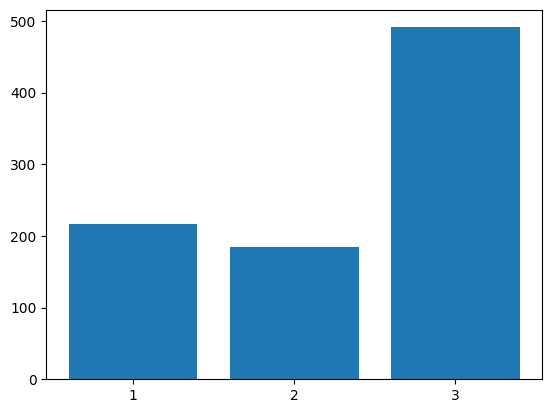

In [55]:
pclass_population = df.groupby('Pclass').size()

plt.bar(pclass_population.index, pclass_population.values)
plt.xticks(pclass_population.index)

([<matplotlib.axis.XTick at 0x7a514f467ed0>,
 [Text(0.0, 0, 'female'), Text(1.0, 0, 'male')])

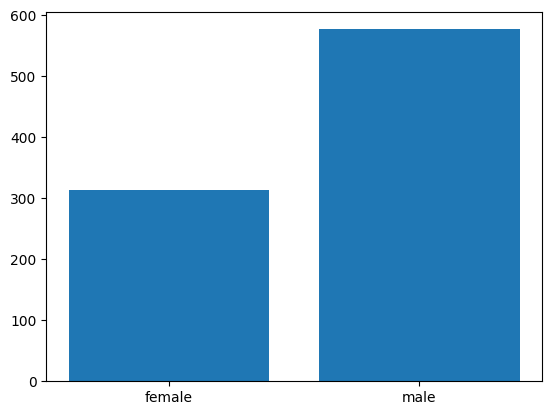

In [57]:
survived_by_sex = df.groupby('Sex')['Survived'].size()

plt.bar(survived_by_sex.index, survived_by_sex.values)
plt.xticks(survived_by_sex.index)

Вопрос: Правда ли, что в более дорогих классах ехали более взрослые пассажиры?

Ответ: Да, чем дороже класс, тем старше пассажиры: в 1 классе средний возраст 38.2 года, во 2 классе 29.9, в 3 классе 25.1